In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
df = pd.read_csv('insurance.csv')
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()
print("\nSummary Statistics:")
df.describe()

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Summary Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


/tmp/ipykernel_11279/2223976105.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set1', ax=axes[1,0])
/tmp/ipykernel_11279/2223976105.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', palette='Set2', ax=axes[1,1])


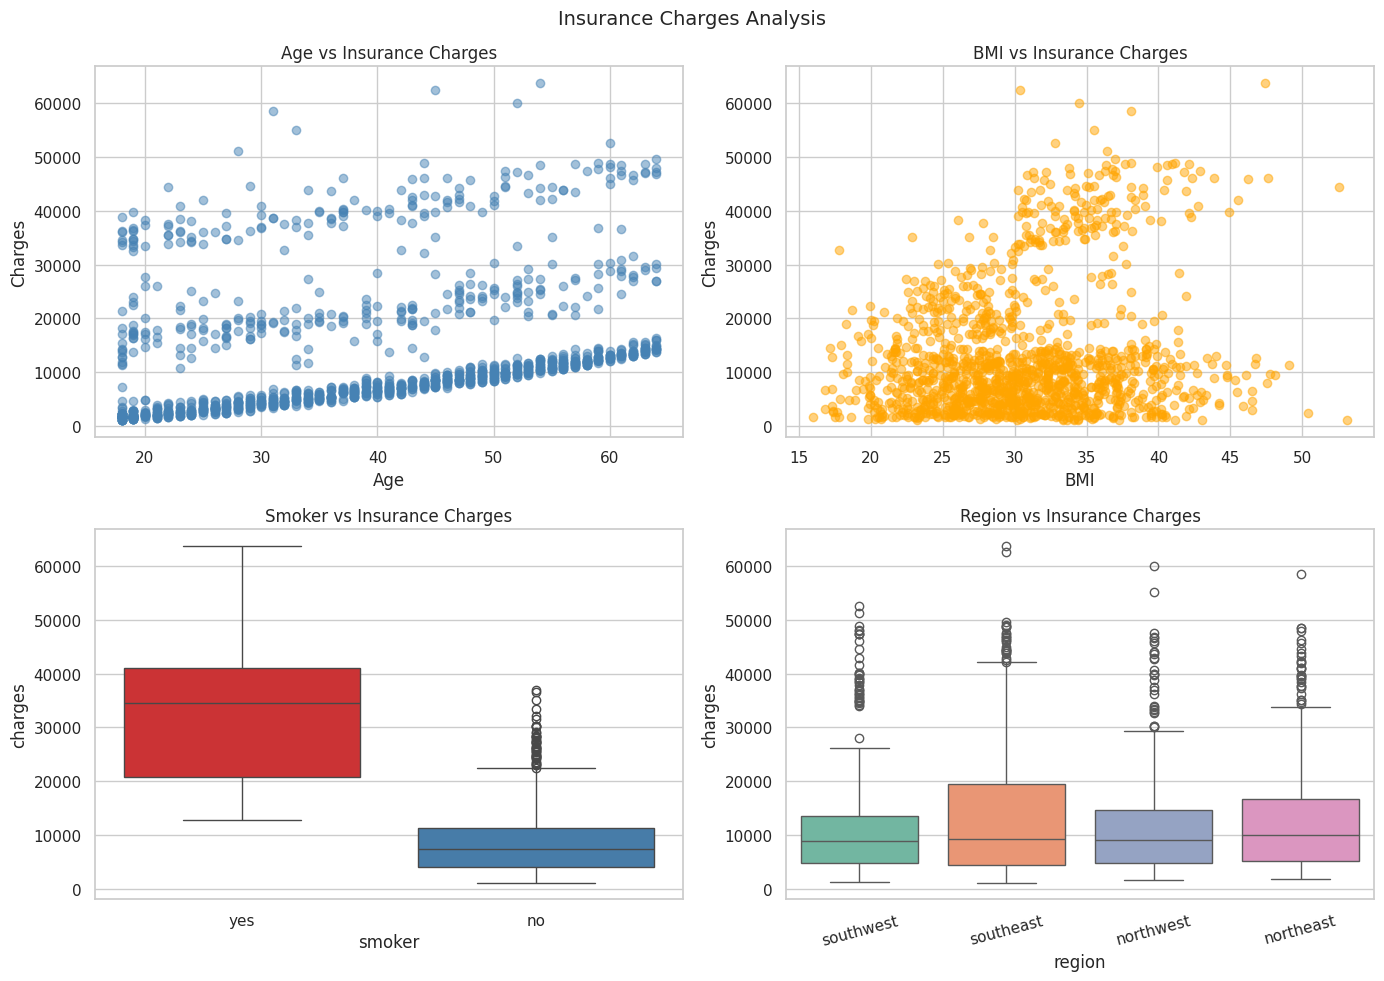

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age vs Charges
axes[0,0].scatter(df['age'], df['charges'], color='steelblue', alpha=0.5)
axes[0,0].set_title('Age vs Insurance Charges')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Charges')

# BMI vs Charges
axes[0,1].scatter(df['bmi'], df['charges'], color='orange', alpha=0.5)
axes[0,1].set_title('BMI vs Insurance Charges')
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Charges')

# Smoker vs Charges
sns.boxplot(data=df, x='smoker', y='charges', palette='Set1', ax=axes[1,0])
axes[1,0].set_title('Smoker vs Insurance Charges')

# Region vs Charges
sns.boxplot(data=df, x='region', y='charges', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Region vs Insurance Charges')
axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('Insurance Charges Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Convert text to numbers
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['region'] = df['region'].map({
    'northeast': 0,
    'northwest': 1,
    'southeast': 2,
    'southwest': 3
})

print("✅ Encoding done!")
df.head()

✅ Encoding done!


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [9]:
# Features (X) and Target (y)
X = df.drop(columns=['charges'])
y = df['charges']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1070, 6)
Testing size: (268, 6)


In [10]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("✅ Model trained successfully!")

✅ Model trained successfully!


MAE  (Mean Absolute Error):  $4,186.51
RMSE (Root Mean Sq Error):   $5,799.59
R²   (Accuracy Score):        0.7833


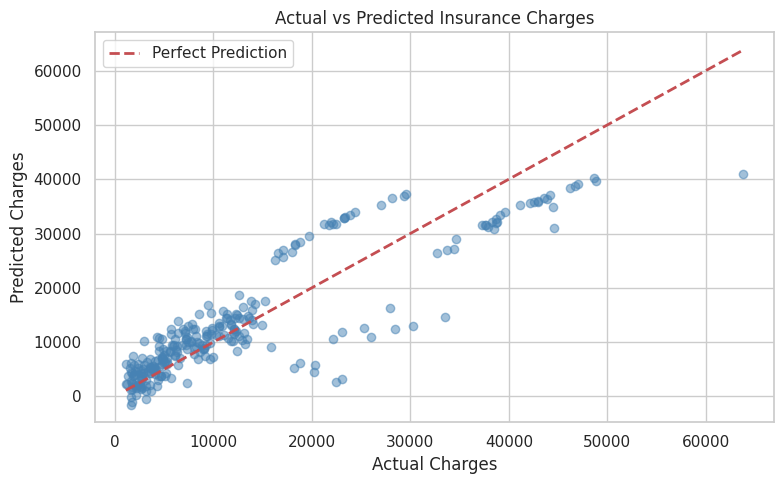

In [11]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error):  ${mae:,.2f}")
print(f"RMSE (Root Mean Sq Error):   ${rmse:,.2f}")
print(f"R²   (Accuracy Score):        {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.legend()
plt.tight_layout()
plt.show()

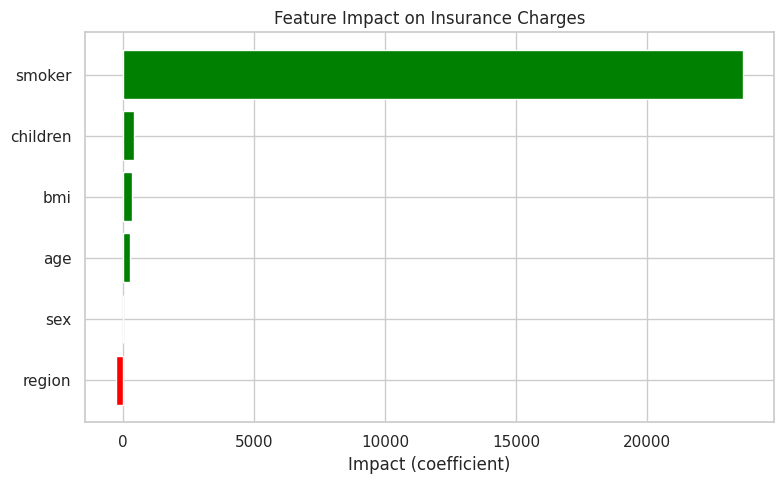


Feature Impacts:
    Feature        Impact
5    region   -271.284266
1       sex    -18.791457
0       age    257.056264
2       bmi    335.781491
3  children    425.091456
4    smoker  23647.818096


In [12]:
# Show which features affect charges the most
feature_names = X.columns.tolist()
coefficients = model.coef_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Impact': coefficients
}).sort_values('Impact', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['red' if x < 0 else 'green' for x in feat_df['Impact']]
plt.barh(feat_df['Feature'], feat_df['Impact'], color=colors)
plt.title('Feature Impact on Insurance Charges')
plt.xlabel('Impact (coefficient)')
plt.tight_layout()
plt.show()

print("\nFeature Impacts:")
print(feat_df)

## Conclusion
- Insurance dataset had 1338 records and no missing values
- Smoking is by far the biggest factor in insurance charges (+$23,647)
- Age and BMI also positively impact charges
- Region and sex have minimal impact
- Linear Regression achieved R² score of 0.78 (78% accuracy)
- MAE of $4,186 means predictions are off by ~$4K on average
- Model performs well for non-smokers but struggles with extreme smoker costs